In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

ROOT = Path.cwd().parents[1]
sys.path.insert(0, str(ROOT))

from src.paths import OUTPUT, FIG_OUTPUT
from src.fig import fig_3d

# 1.x Model

In [2]:
model_number = '1'

PATH_END = '01-run/metrics_summary.csv'
letter = ['A', 'B', 'C', 'D']
dict_path = {}

for i, j in zip(range(4), letter):
    dict_path[f'df_{model_number}_{i}'] = f'{model_number}.{i}-fc-rand-{j}'

df_1_0 = pd.read_csv(OUTPUT / dict_path[f'df_{model_number}_0'] / PATH_END)
df_1_1 = pd.read_csv(OUTPUT / dict_path[f'df_{model_number}_1'] / PATH_END)
df_1_2 = pd.read_csv(OUTPUT / dict_path[f'df_{model_number}_2'] / PATH_END)
df_1_3 = pd.read_csv(OUTPUT / dict_path[f'df_{model_number}_3'] / PATH_END)

Analytic Benchmark
SSE = 115.3004  RMSE = 0.017445
Coefficients: a = -0.137149, b = -0.079070, c = -0.056295


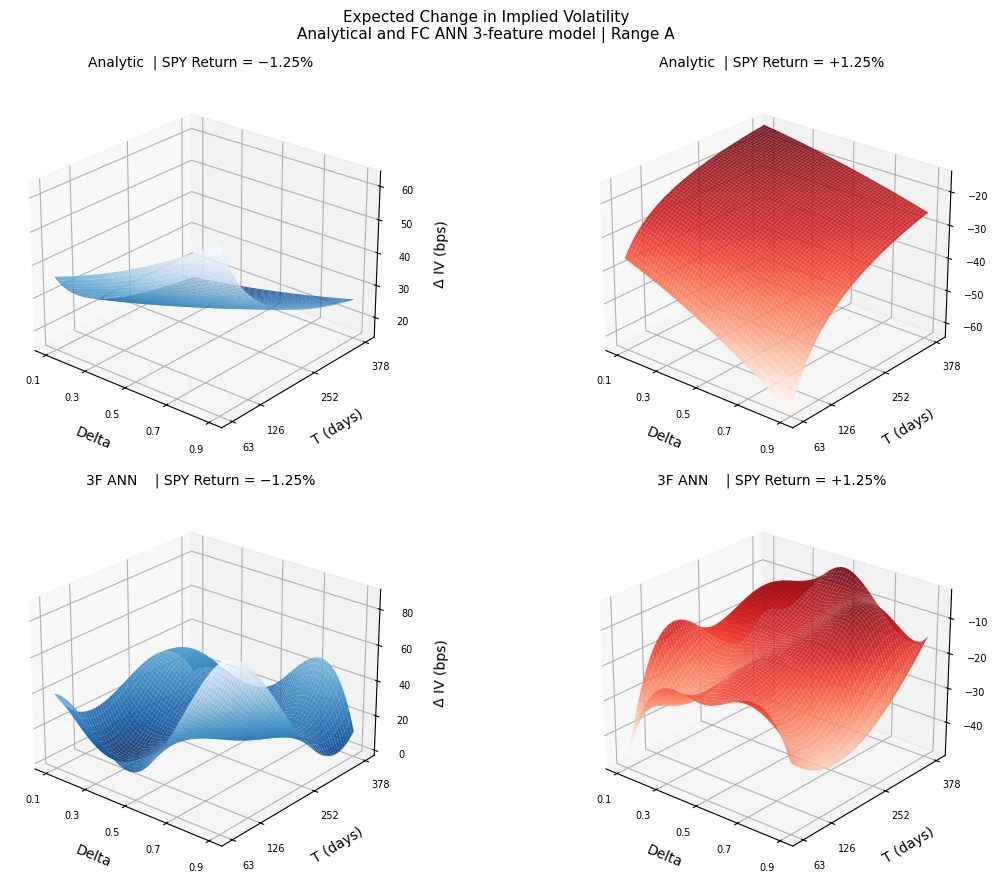

Analytic Benchmark
SSE = 38.6267  RMSE = 0.017226
Coefficients: a = -0.092295, b = -0.154601, c = -0.144622


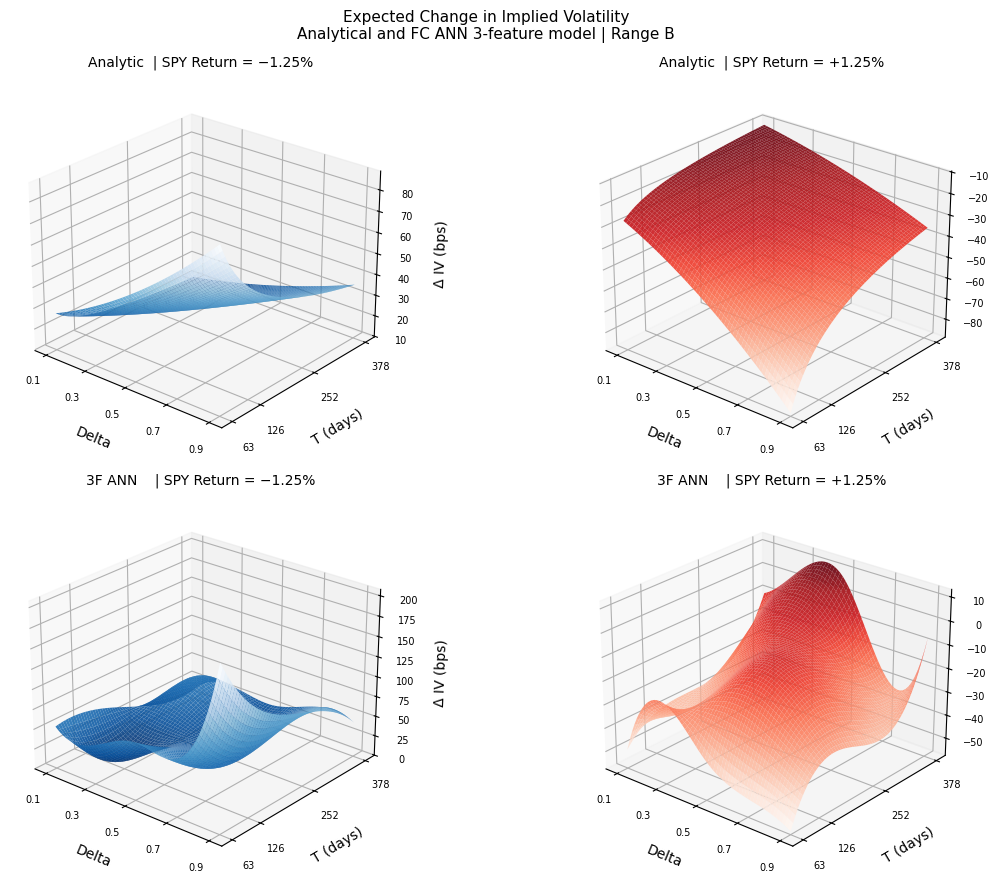

Analytic Benchmark
SSE = 64.9134  RMSE = 0.016269
Coefficients: a = -0.078536, b = -0.092386, c = -0.081882


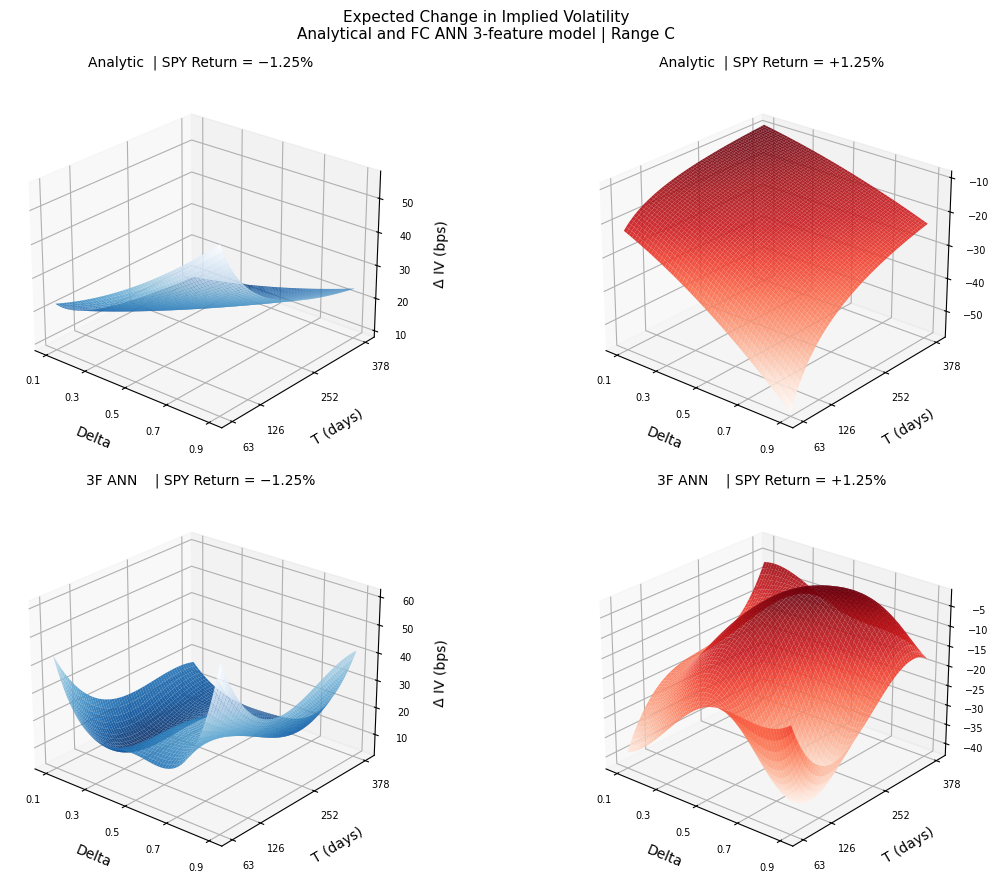

Analytic Benchmark
SSE = 8.3745  RMSE = 0.008338
Coefficients: a = -0.165665, b = -0.000516, c = 0.032673


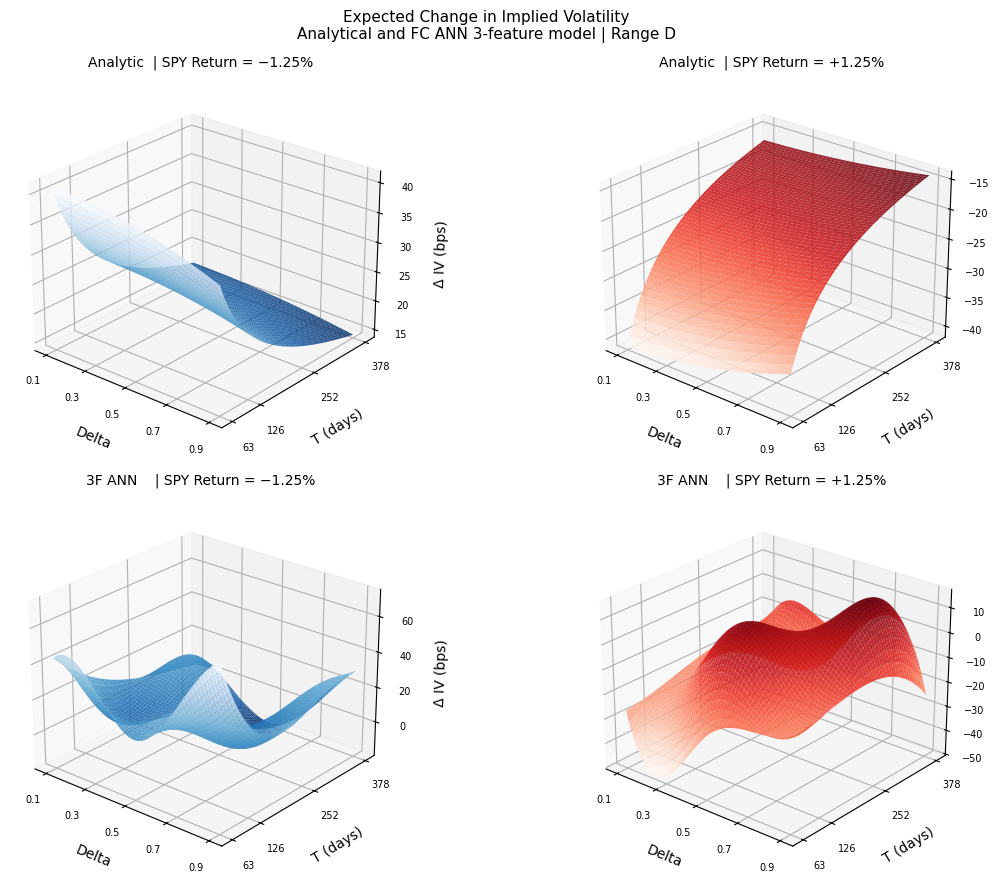

In [3]:
fig_A = fig_3d(set_letter='A', output_path=Path(FIG_OUTPUT / '1.0-range-A.png'))
fig_B = fig_3d(set_letter='B', output_path=Path(FIG_OUTPUT / '1.1-range-B.png'))
fig_C = fig_3d(set_letter='C', output_path=Path(FIG_OUTPUT / '1.2-range-C.png'))
fig_D = fig_3d(set_letter='D', output_path=Path(FIG_OUTPUT / '1.3-range-D.png'))

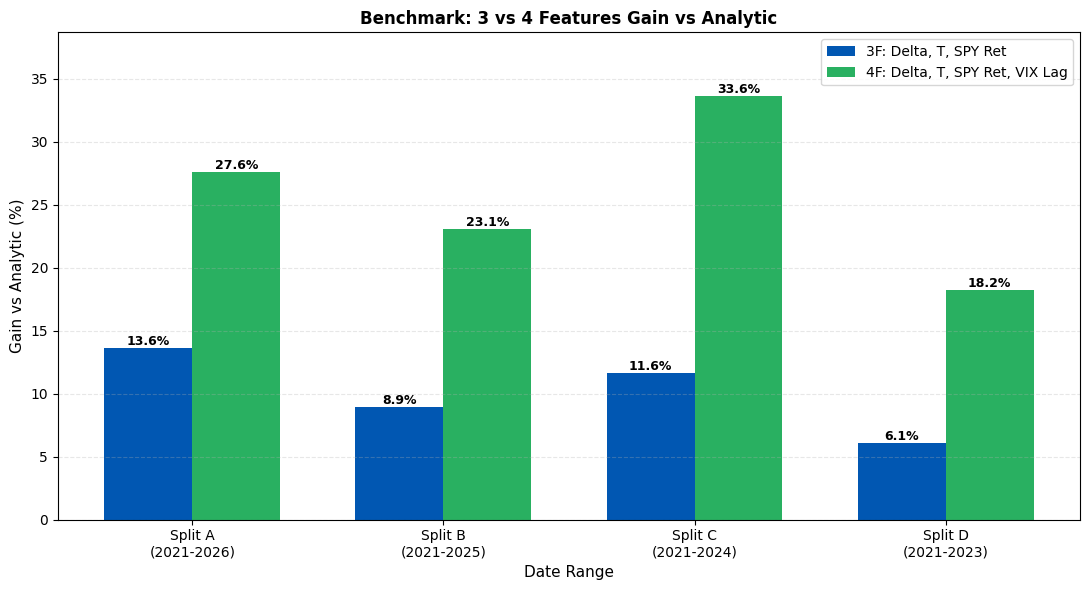

In [5]:
# Extract gains for 3F and 4F across all ranges
gains_3f = []
gains_4f = []
date_ranges = []

for idx, ltr in enumerate(letter):
    csv_path = OUTPUT / dict_path[f'df_{model_number}_{idx}'] / PATH_END
    df_metrics = pd.read_csv(csv_path)

    gain_3f = float(df_metrics[df_metrics['Model'] == 'ANN-3F']['Gain_vs_Analytic'].values[0].strip('%'))
    gain_4f = float(df_metrics[df_metrics['Model'] == 'ANN-4F']['Gain_vs_Analytic'].values[0].strip('%'))

    gains_3f.append(gain_3f)
    gains_4f.append(gain_4f)
    date_ranges.append(f'Split {ltr}\n(2021-202{6-idx})')

# Create bar chart
fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(date_ranges))
width = 0.35

bars1 = ax.bar(x - width/2, gains_3f, width, label='3F: Delta, T, SPY Ret', color="#0157B2")
bars2 = ax.bar(x + width/2, gains_4f, width, label='4F: Delta, T, SPY Ret, VIX Lag', color="#29B061")

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold', )

ax.set_xlabel('Date Range', fontsize=11)
ax.set_ylabel('Gain vs Analytic (%)', fontsize=11)
ax.set_title('Benchmark: 3 vs 4 Features Gain vs Analytic', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(date_ranges)
ax.legend(loc='upper right', fontsize=10)
ax.set_ylim(0, max(max(gains_3f), max(gains_4f)) * 1.15)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(FIG_OUTPUT / '1.x-gain.png', dpi=150, bbox_inches='tight')
plt.show()